**Name: Ameya Satish Khond**  
**SJSU ID: 019136845**

# Q1.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

X = np.array([
    [2, 5],
    [4, 4],
    [1, 3],
    [3, 6],
    [5, 2],
], dtype=float)

In [41]:
pca = PCA(n_components=2)
pca.fit_transform(X)

pc1 = pca.components_[0]
pc2 = pca.components_[1]

print("PC1 (components_[0]):", pca.components_[0])
print("\nPC2 (components_[1]):", pca.components_[1])
print("\n1D reduced feature (projection on PC1):", X_pca[:, 0])

PC1 (components_[0]): [ 0.70710678 -0.70710678]

PC2 (components_[1]): [0.70710678 0.70710678]

1D reduced feature (projection on PC1): [-1.78736197  1.48666751 -1.23425633 ... -0.27978167 -1.07411186
 -0.75654462]


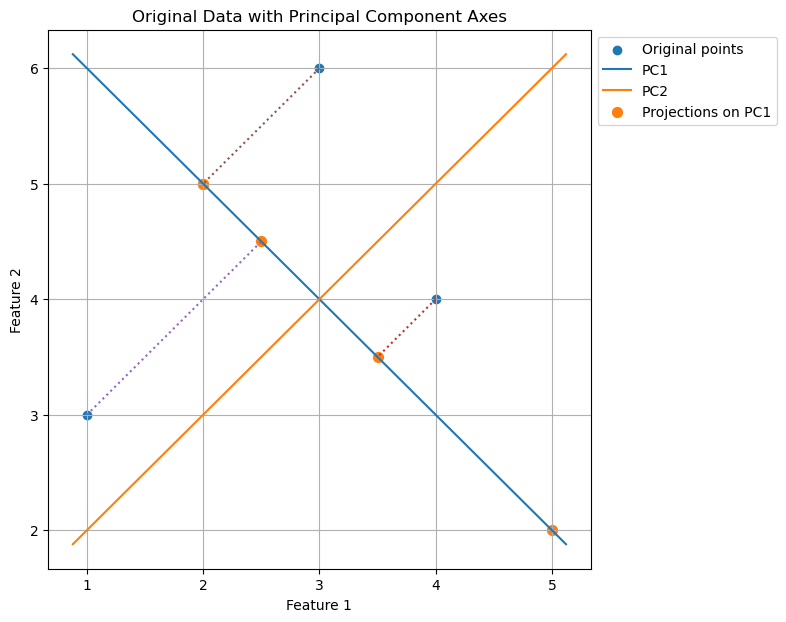

In [42]:
mean = X.mean(axis=0)
pc1_vec = pc1
pc2_vec = pc2
plt.figure(figsize=(7, 7))

plt.scatter(X[:, 0], X[:, 1], label="Original points")

scale = 3
pc1_line = np.vstack([mean - scale * pc1_vec, mean + scale * pc1_vec])
pc2_line = np.vstack([mean - scale * pc2_vec, mean + scale * pc2_vec])
plt.plot(pc1_line[:, 0], pc1_line[:, 1], label="PC1")
plt.plot(pc2_line[:, 0], pc2_line[:, 1], label="PC2")

X_centered = X - mean
proj_lengths = X_centered @ pc1_vec 
projected_points = mean + np.outer(proj_lengths, pc1_vec)
plt.scatter(projected_points[:, 0], projected_points[:, 1],
s=50,label="Projections on PC1")

for i in range(X.shape[0]):
    plt.plot([X[i, 0], projected_points[i, 0]],
        [X[i, 1], projected_points[i, 1]],
        linestyle="dotted")
    
plt.title("Original Data with Principal Component Axes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

# Q2. 
This assignment extends the work we practiced during the in-class activity on
manifold learning. In class, each group focused on one non-linear method. For this assignment,
you will complete the full workflow individually for all five methods. The structure follows the
same steps used in the in-class activity. This provides a familiar reference for how to organize
your explanations, code, visualizations, and interpretations.
You will compare t-SNE, UMAP, Isomap, LLE, Kernel PCA, and use PCA as the baseline.

# Part 1 - Dataset Description (write this in your report)

Dataset: Two-Moons Synthetic Dataset (from scikit-learn)
Samples: 2000
Feature Dimensions: 2
Labels: Two classes (moon 1 and moon 2)

Description:
The Two-Moons dataset consists of two interleaving half-circle shapes (“moons”). Each sample is a point in 2D space, and the dataset includes optional noise that adds natural variation. Even though the data is only two-dimensional, the two classes cannot be separated using a linear boundary.

Why it contains nonlinear patterns:
The structure of the dataset is intrinsically curved—the moons wrap around each other. Linear projections like PCA cannot untangle the shape, making this a classic example of a nonlinear manifold. This is why the dataset is widely used to evaluate manifold learning techniques such as t-SNE, UMAP, Isomap, LLE, and Kernel PCA.


In [43]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding

import umap


In [44]:
X, y = make_moons(n_samples=2000, noise=0.1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Part 2 - Method Intuition (Moons Dataset)  

**1. PCA (Baseline):**

- **Intuition:** Finds the linear directions of maximum variance.

- **Preserves:** Global linear variance structure.

- **Key hyperparameter:** Number of components.

- **Limitation for Moons:** Cannot untangle curved shapes → clusters overlap.

**2. t-SNE:**

- **Intuition:** Converts distances into probability similarities and preserves small neighborhoods.

- **Preserves:** Local structure; produces tight, compact clusters.

- **Key hyperparameter:** Perplexity.

- **Why good for Moons:** Very effective at separating curved, intertwined clusters.

**3. UMAP:**

- **Intuition:** Builds a high-dimensional graph of relationships and optimizes a low-dimensional graph that matches it.

- **Preserves:** Local structure and some global relationships.

- **Key hyperparameters:** n_neighbors, min_dist.

- **Why good for Moons:** Captures the curved boundary and keeps clusters well-separated.

**4. Isomap:**

- **Intuition:** Uses shortest-path distances on a k-nearest-neighbor graph to approximate geodesic (manifold) distances.

- **Preserves:** Global manifold structure.

- **Key hyperparameter:** n_neighbors.

- **Why good for Moons:** Can begin to “unroll” curved shapes by respecting geodesic distances.

**5. LLE (Locally Linear Embedding):**

- **Intuition:** Represents each point as a linear combination of its neighbors; embedding preserves these reconstruction weights.

- **Preserves:** Local linear structure.

- **Key hyperparameter:** n_neighbors.

- **Why good for Moons:** Good at unfolding curved manifolds by preserving local geometry.

**6. Kernel PCA:**

- **Intuition:** Applies PCA in a high-dimensional feature space induced by a nonlinear kernel (e.g., RBF).

- **Preserves:** Nonlinear variance in the transformed feature space.

- **Key hyperparameter:** gamma (for the RBF kernel).

- **Why good for Moons:** The nonlinear kernel can separate the two moon shapes into distinct components.

# Part 3 and Part 4 - Full Python Block Using Moons

    PCA Baseline

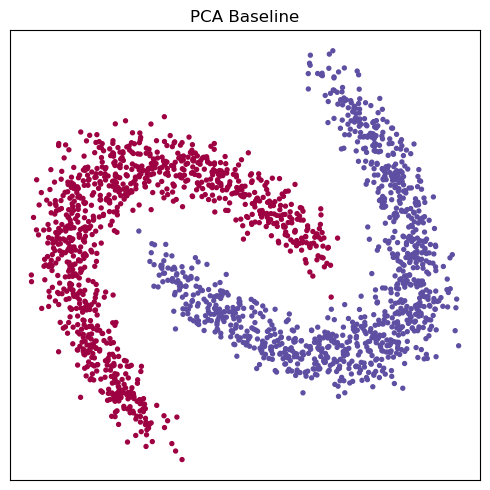

In [45]:
def plot_embedding(X_embedded, y, title):
    plt.figure(figsize=(5,5))
    plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y, s=8, cmap='Spectral')
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()

plot_embedding(X_pca, y, "PCA Baseline")


    t-SNE (3 perplexity values)

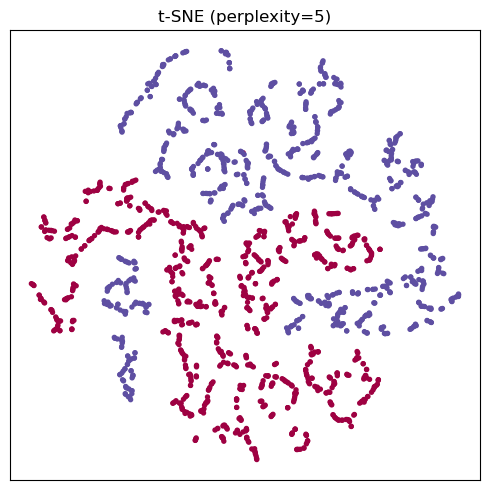

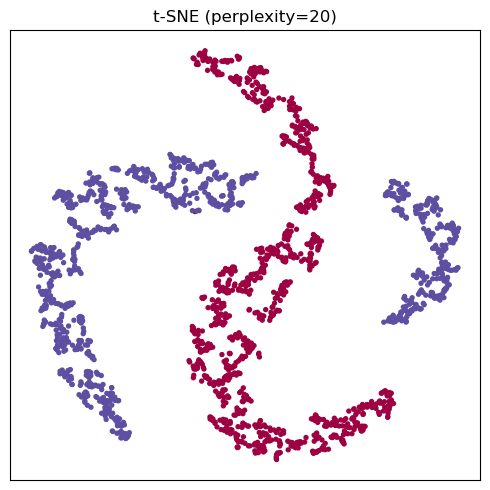

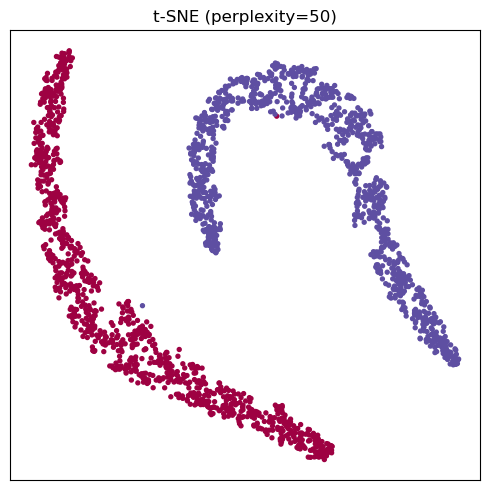

In [46]:
for perp in [5, 20, 50]:
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate='auto', init='random')
    X_tsne = tsne.fit_transform(X_scaled)
    plot_embedding(X_tsne, y, f"t-SNE (perplexity={perp})")


    UMAP

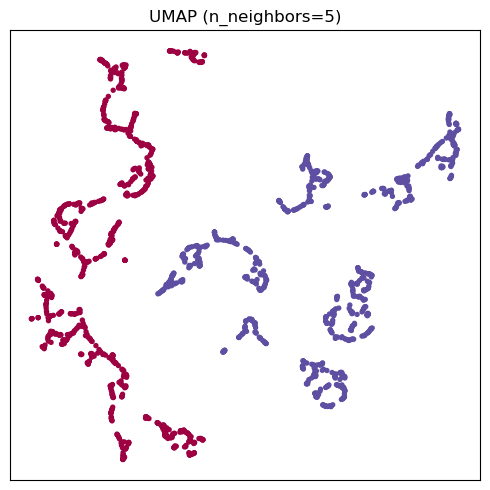

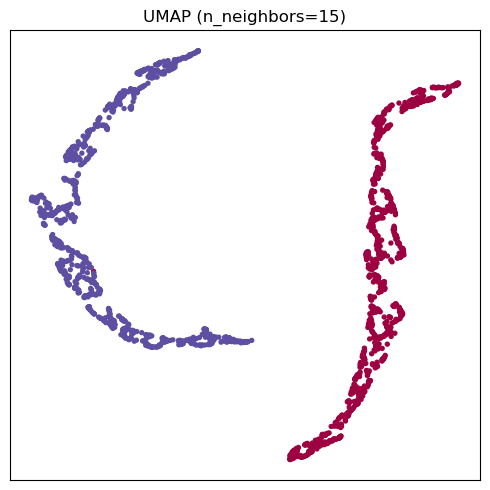

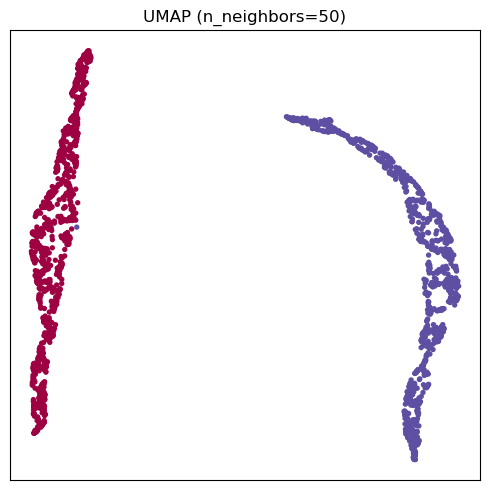

In [47]:
for n in [5, 15, 50]:
    reducer = umap.UMAP(n_components=2, n_neighbors=n, min_dist=0.1)
    X_umap = reducer.fit_transform(X_scaled)
    plot_embedding(X_umap, y, f"UMAP (n_neighbors={n})")


    Isomap

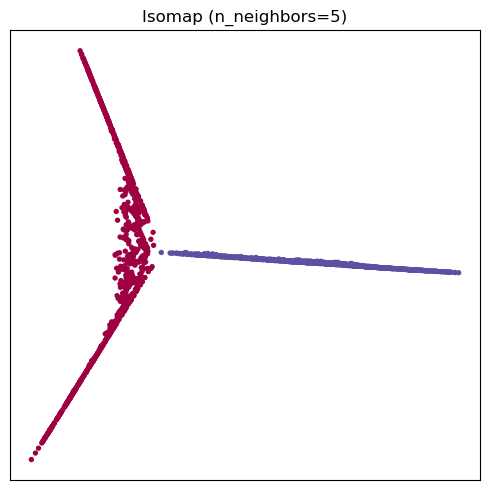

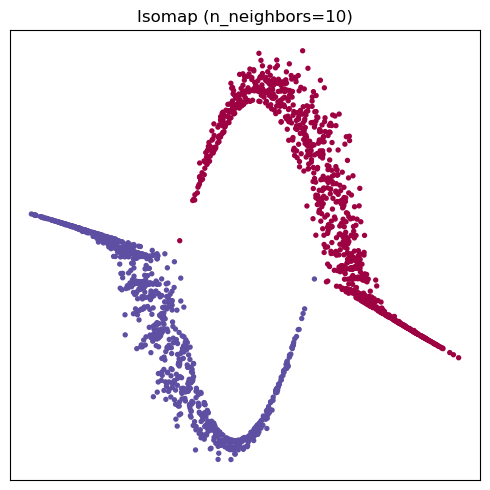

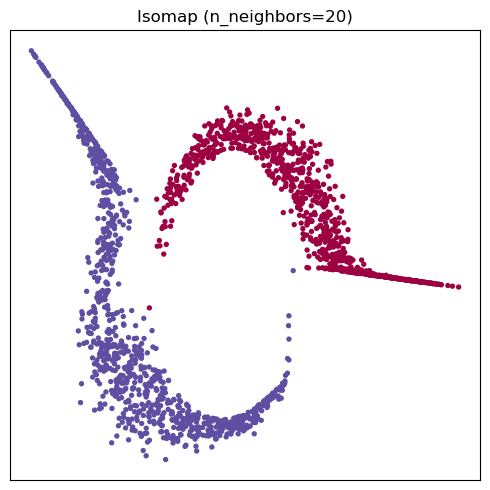

In [48]:
for n in [5, 10, 20]:
    iso = Isomap(n_neighbors=n, n_components=2)
    X_iso = iso.fit_transform(X_scaled)
    plot_embedding(X_iso, y, f"Isomap (n_neighbors={n})")


    LLE

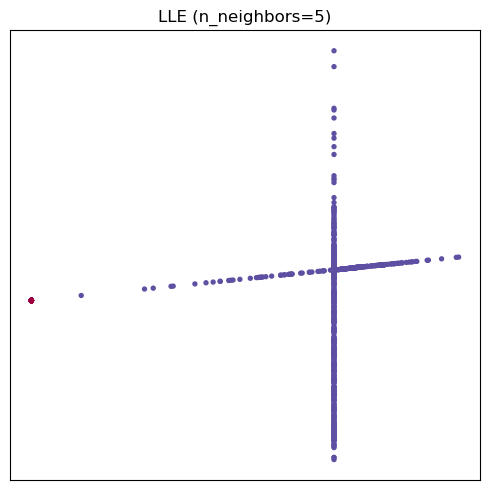

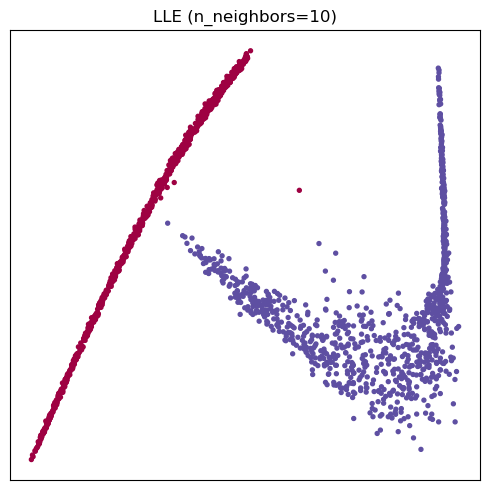

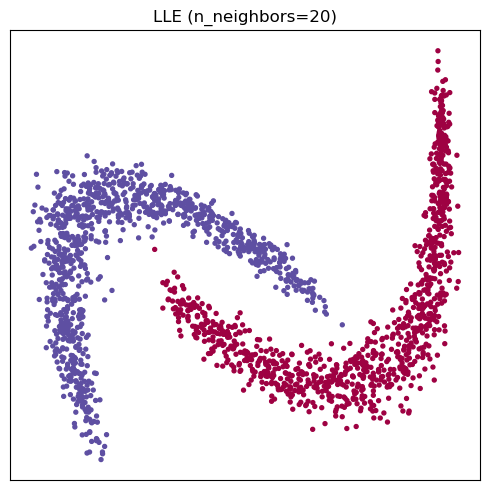

In [49]:
for n in [5, 10, 20]:
    lle = LocallyLinearEmbedding(n_neighbors=n, n_components=2)
    X_lle = lle.fit_transform(X_scaled)
    plot_embedding(X_lle, y, f"LLE (n_neighbors={n})")


    Kernel PCA

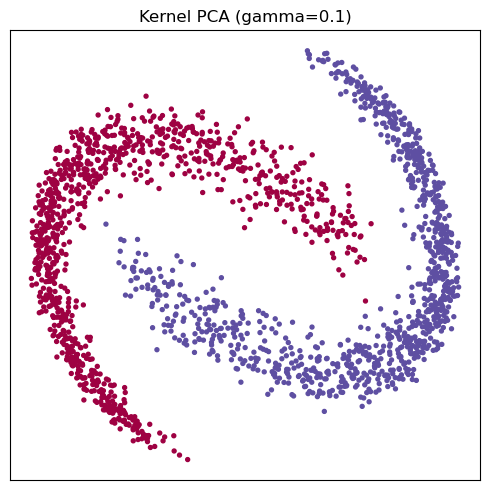

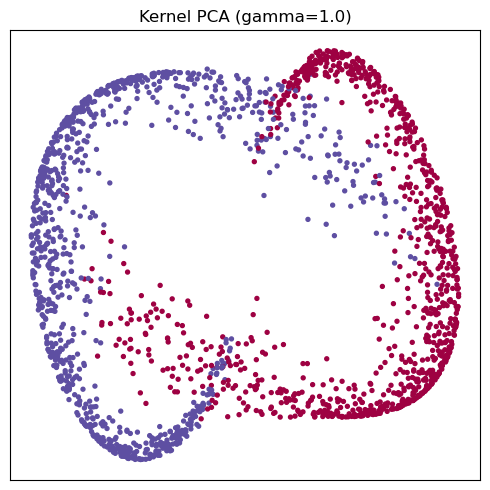

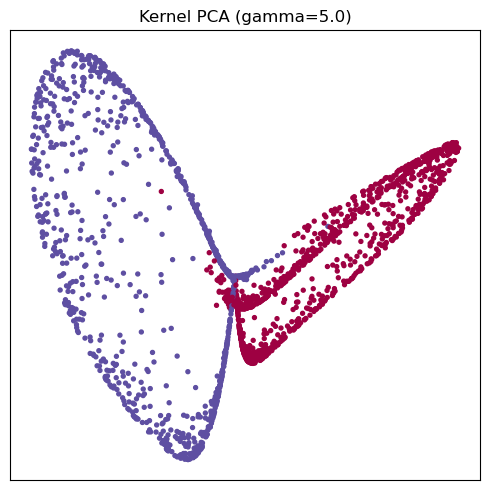

In [50]:
for gamma in [0.1, 1.0, 5.0]:
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X_scaled)
    plot_embedding(X_kpca, y, f"Kernel PCA (gamma={gamma})")


# Part 5 - Comparative Analysis  
The Moons dataset contains two curved, interlocking shapes, making it an effective test case for nonlinear dimensionality-reduction techniques. PCA serves as the linear baseline, and its plot shows heavy overlap between the two moons, confirming that straight-line projections cannot separate intrinsically curved structures. Nonlinear methods perform significantly better, each in different ways.

t-SNE produces very compact, well-separated clusters when the perplexity is appropriately chosen. Lower perplexity values highlight fine local details but may create fragmentation, while higher values smooth the clusters and improve global coherence. UMAP provides a strong balance between local and global structure, with n_neighbors controlling how tightly the moons are separated. Smaller values preserve fine curvature, while larger values reveal the overall manifold shape more clearly. Compared to t-SNE, UMAP is generally more stable across parameter choices.

Isomap emphasizes global geodesic structure. With an appropriate number of neighbors, it partially “unrolls” the moons, but too few neighbors create disconnected graphs and too many oversmooth the manifold. LLE performs well at capturing local linearity, but it is more sensitive to the neighborhood size and may distort global structure. Kernel PCA with an RBF kernel also separates the moons, though its performance depends heavily on the gamma parameter. Overall, nonlinear methods significantly outperform PCA, with UMAP and t-SNE providing the clearest separation.